In [1]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse

import matplotlib as mpl
def set_vis_default(font = 1.6, circle_marker = 1.):
    mpl.rcParams['font.family'] = 'Arial'
    plt.rcParams.update(plt.rcParamsDefault)
#     %matplotlib inline
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('seaborn-v0_8-whitegrid')

    sns.set_context('paper',font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams['font.family'] = 'Arial'



In [3]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF/spatial_annotation/Reference_data'
file_path = Path(base_path)

file_name = 'atlas_Disease.h5ad'
atlas_adata = sc.read(file_path / file_name)
atlas_adata

AnnData object with n_obs × n_vars = 178799 × 1741
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'leiden_0p5_ct_v0', 'leiden_1p0_ct_v0', 'leiden_2p5_ct_v0', 'tmp', 'leiden_2p5_epi_v1', 'leiden_2p5_epi', 'leiden_2p5_epi_v2', 'leiden_2p5_epi_v3', 'leiden_2p5_epi_v7', 'leiden_2p5_epi_v4', 'leiden_1p_fibro_v1', 'ct_anno'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'disease_colors', 'leiden_2p0_colors', 'leiden_2p5_colors', 'leiden_2p5_ct_v0_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [14]:
color_dict = {'AT1': '#ffff00',
 'AT2': '#1ce6ff',
 'Aberrant Basaloid': '#ff34ff',
 'Alveolar Mph CCL3+': '#ff4a46',
 'Alveolar Mph proliferating': '#008941',
 'Alveolar macrophages': '#006fa6',
 'B cells': '#a30059',
 'Basal': '#ffdbe5',
 'Basal-Prolif': '#7a4900',
 'CD4 T cells': '#0000a6',
 'CD8 T cells': '#63ffac',
 'Ciliated': '#b79762',
 'Ciliated MUC5AC+': '#004d43',
 'Ciliated SCGB3A2+': '#8fb0ff',
 'Classical monocytes': '#997d87',
 'DC1': '#5a0007',
 'DC2': '#809693',
 'EC aerocyte capillary': '#6a3a4c',
 'EC arterial': '#1b4400',
 'EC general capillary': '#4fc601',
 'EC venous systemic': '#3b5dff',
 'FB': '#4a3b53',
 'FB COL1A1+': '#ff2f80',
 'FB ECM': '#61615a',
 'FB ECM CHI3L2+': '#ba0900',
 'FB ECM COL1A1+': '#6b7900',
 'FB ECM SOX4+': '#00c2a0',
 'FB HAS1+': '#ffaa92',
 'Interstitial Mph perivascular': '#ff90c9',
 'Ionocyte': '#b903aa',
 'Lymphatic EC mature': '#d16100',
 'Mast cells': '#ddefff',
 'Mesothelial': '#000035',
 'Migratory DCs': '#7b4f4b',
 'Monocyte-derived Mph': '#a1c299',
 'NK cells': '#300018',
 'Neuroendocrine': '#0aa6d8',
 'Non-classical monocytes': '#013349',
 'Pericytes': '#00846f',
 'Plasma cells': '#372101',
 'Plasmacytoid DCs': '#ffb500',
 'SCGB1A1+/SCGB3A1+/SCGB3A2+': '#c2ffed',
 'SCGB3A1+/SCGB3A2+': '#a079bf',
 'SMCs': '#cc0744',
 'SMG duct': '#c0b9b2',
 'SMG-Serous': '#c2ff99',
 'Secretory MUC5AC+': '#001e09',
 'Secretory MUC5B+': '#00489c',
 'Smooth muscle': '#6f0062',
 'Squamous': '#0cbd66',
 'Suprabasal': '#eec3ff',
 'Suprabasal SCGB1A1+': '#456d75',
 'myo-FB': '#b77b68'}

/tmp/ipykernel_3448270/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


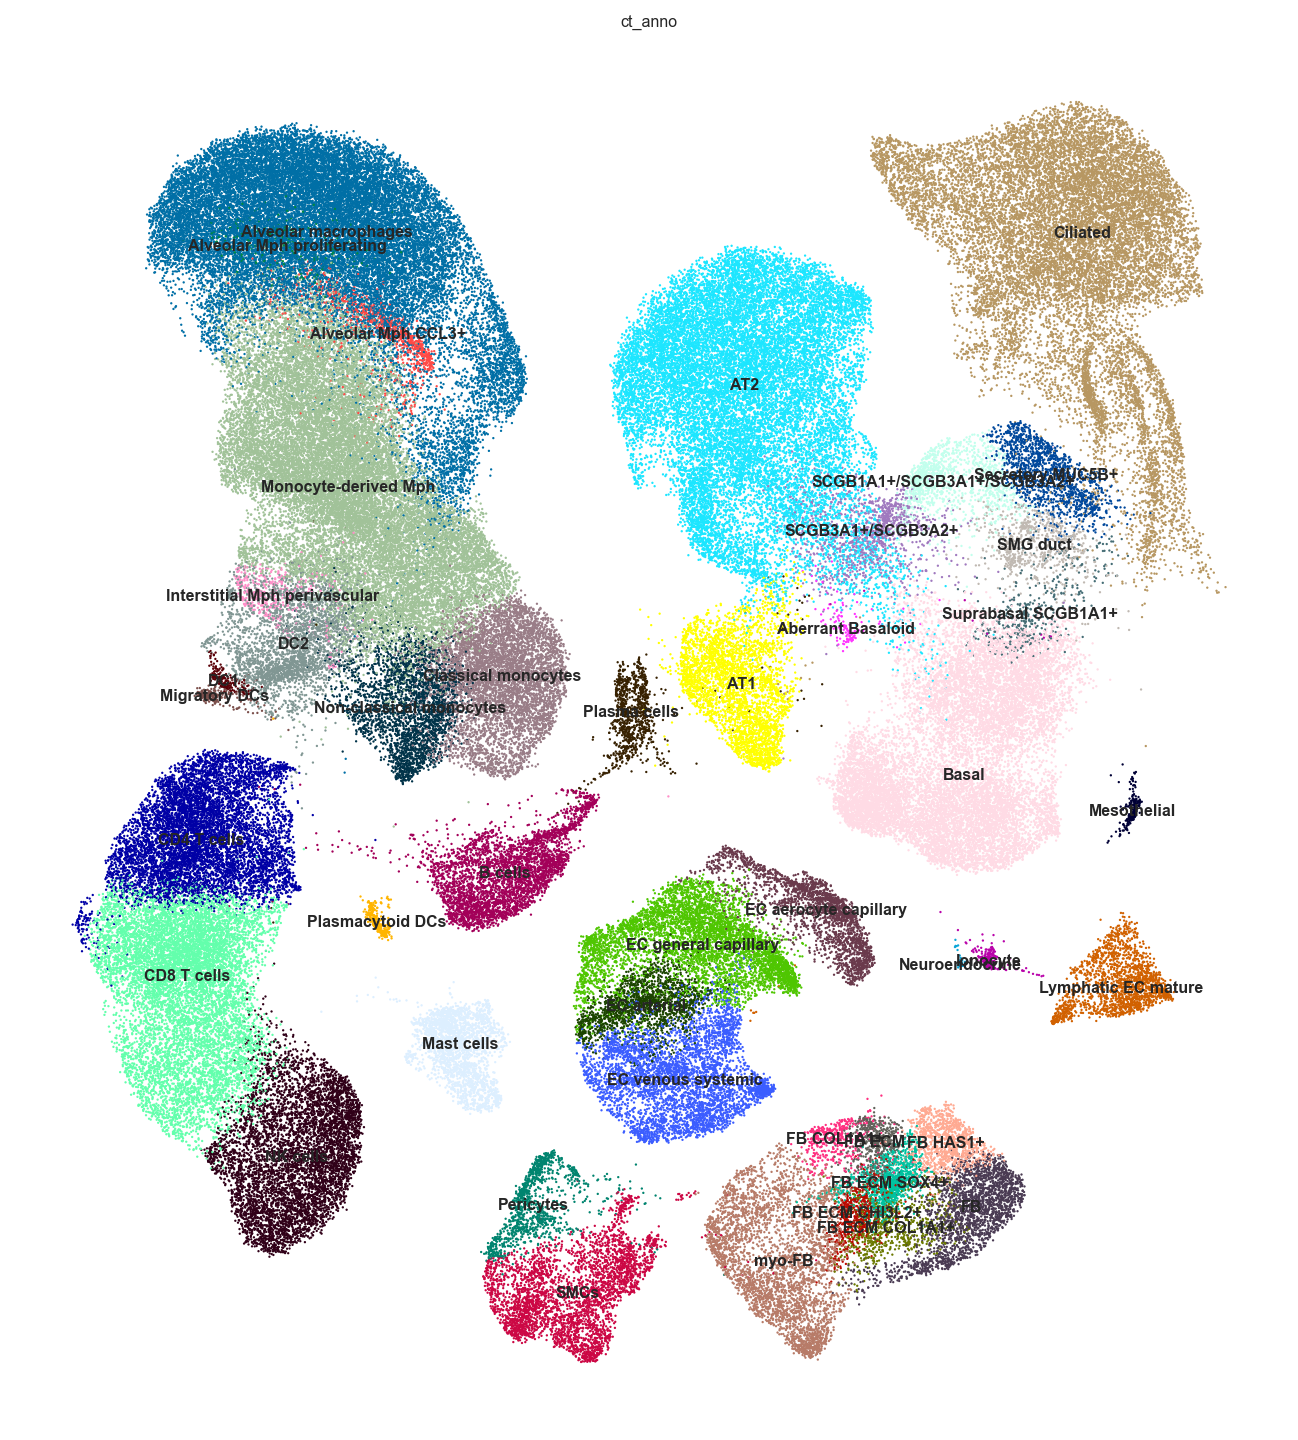

In [15]:
set_vis_default(font = .8, circle_marker = 3.)



adata_vis = atlas_adata

fig, axs = plt.subplots(1, 2, figsize=(24, 12), dpi = 150, gridspec_kw={'wspace': .2, 'hspace': 0.05})


sc.pl.umap(
    adata_vis, color='ct_anno', 
    size=5, frameon=False, show=False, ax=axs[0], 
    palette = color_dict, 
#     groups = groups#,
    legend_loc = 'on data' 
)
axs[0].legend(bbox_to_anchor=(1., 1.0))
axs[1].remove()

plt.show()
plt.close()

## Please run script files in ./src first

In [5]:
save_bath_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
save_path = Path(save_bath_path) / 'spatial_annotation/fitted_spatial_nn/VUILD107MA_Disease'
file_path = save_path

save_file_name = 'adata_all.h5ad'
adata_all = sc.read(save_path / save_file_name)
adata_inte_mapped = sc.read(save_path / 'adata_inte_mapped.h5ad')

/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
adata_inte_mapped

AnnData object with n_obs × n_vars = 68413 × 1741
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'index', 'sample', 'patient', 'cell_id_y', 'sample_type', 'sample_affect', 'disease_status', 'percent_pathology', 'tma', 'run', 'final_CT', 'final_lineage', 'CNiche', 'TNiche', 'lumen_id', 'lumen_rank', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'super_adj_x_centroid', 'super_adj_y_centroid', 'nCount_RNA', 'nFeature_RNA', 'perc_negcontrolprobe', 'perc_negcontrolcodeword', 'perc_unassigned', 'perc_negcontrolorunassigned', 'n_genes', 'dataset_idx_y', 'cell_parquet_index', 'cell_type_y', 'predict_mapped_ct_anno', 'predict_mapped_ct_anno_prob'

In [19]:
filter_index = adata_inte_mapped.obs['predict_mapped_ct_anno_prob'] > .5
adata_inte_mapped = adata_inte_mapped[filter_index]

In [20]:
import numpy as np
from scipy.sparse import coo_matrix, csr_matrix

atlas_num = adata_all.obs['atlas_inte'].value_counts()['atlas']
connectivities = adata_all.obsp['connectivities'][atlas_num:, :atlas_num]
connectivities = connectivities[filter_index]
connectivities.data[connectivities.data < 0.5] = 0
connectivities.eliminate_zeros()


X_umap = atlas_adata.obsm['X_umap']


X_umap_sp = connectivities.dot(X_umap)
X_umap_sp = X_umap_sp / connectivities.sum(1).A1[:, None]


/tmp/ipykernel_3448270/2136885907.py:21: RuntimeWarning: invalid value encountered in true_divide
  X_umap_sp = X_umap_sp / connectivities[:, atlas_ct_index].sum(1).A1[:, None]


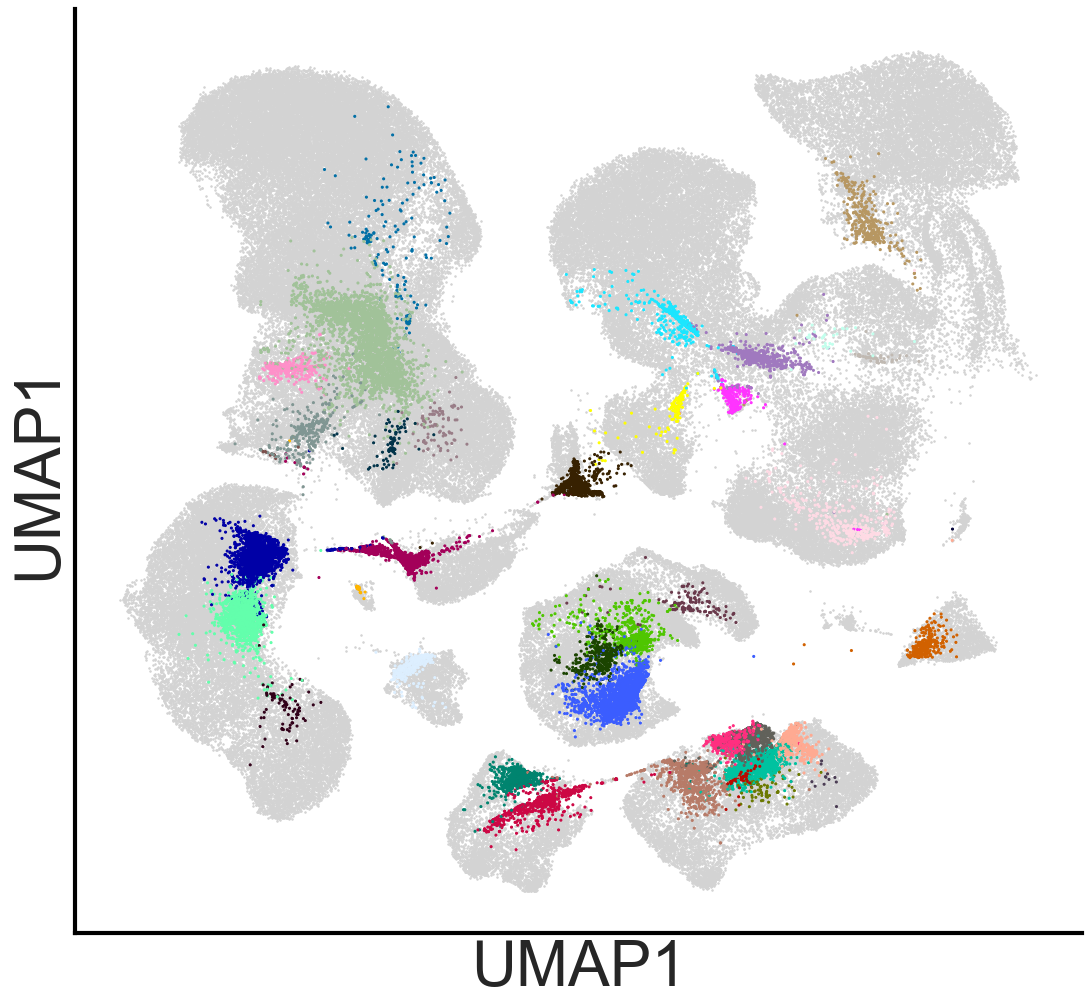

In [22]:
fig, axs = plt.subplots(1, 1, figsize=(13, 12), gridspec_kw={'wspace': .5, 'hspace': 0.2})
X_umap_vis = X_umap_sp
X_umap_sc_vis = atlas_adata.obsm['X_umap']


colors = adata_inte_mapped.obs['predict_mapped_ct_anno'].map(color_dict)

axs.scatter(X_umap_sc_vis[:, 0], X_umap_sc_vis[:, 1], s = 1., color='lightgray')  # Set color to red
for ct in atlas_adata.obs['ct_anno'].value_counts().index.tolist():
    atlas_ct_index = atlas_adata.obs['ct_anno'] == ct

    conn_sum = connectivities[:, atlas_ct_index].sum(1).A1
    if (conn_sum[conn_sum > 0].shape[0] == 0):
        continue
    else:
        thresh = np.quantile(conn_sum[conn_sum > 0], .5)
#     print(thresh)

    sp_index = conn_sum > thresh
    X_umap_sp = connectivities[:, atlas_ct_index].dot(X_umap[atlas_ct_index])
    X_umap_sp = X_umap_sp / connectivities[:, atlas_ct_index].sum(1).A1[:, None]
    X_umap_sp = X_umap_sp[sp_index]
    
    
    axs.scatter(X_umap_sp[:, 0], X_umap_sp[:, 1], s = 2., color=colors[sp_index])  # Set color to red

axs.grid(False)

for tick in axs.xaxis.get_major_ticks():
    tick.tick1line.set_visible(False)
    tick.tick2line.set_visible(False)
    tick.label1.set_visible(False)
    tick.label2.set_visible(False)

axs.set_yticks([])

axs.set_xlabel('UMAP1', fontsize = 45)
axs.set_ylabel('UMAP1', fontsize = 45)

axs.spines['right'].set_visible(False)
axs.spines['top'].set_visible(False)
for spine in ['left', 'bottom']:
    axs.spines[spine].set_color('black')        
    axs.spines[spine].set_linewidth(3)

    
# plt.savefig(f'./save_figs/atlas_sp_mapped.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=1)
plt.show()
plt.close()